# 03 · Group comparisons, post-hoc tests and uncertainty

Move from raw distributions to omnibus/group summaries, effect sizes, explicit post-hoc methods and confidence intervals. The plots emphasize magnitude and uncertainty, not only p-values.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_groups, analyze_posthoc, analyze_confidence_intervals
frame,dataset=load_tabular_demo()
grp=analyze_groups(dataset,responses=('activity','stability'),groups=('group','source'))
post=analyze_posthoc(dataset,response='activity',factor='group',methods=('tukey_hsd','games_howell'))
ci=analyze_confidence_intervals(dataset,bootstrap_resamples=300,random_state=42)

findfont: Failed to find font weight semibold, now using 700.


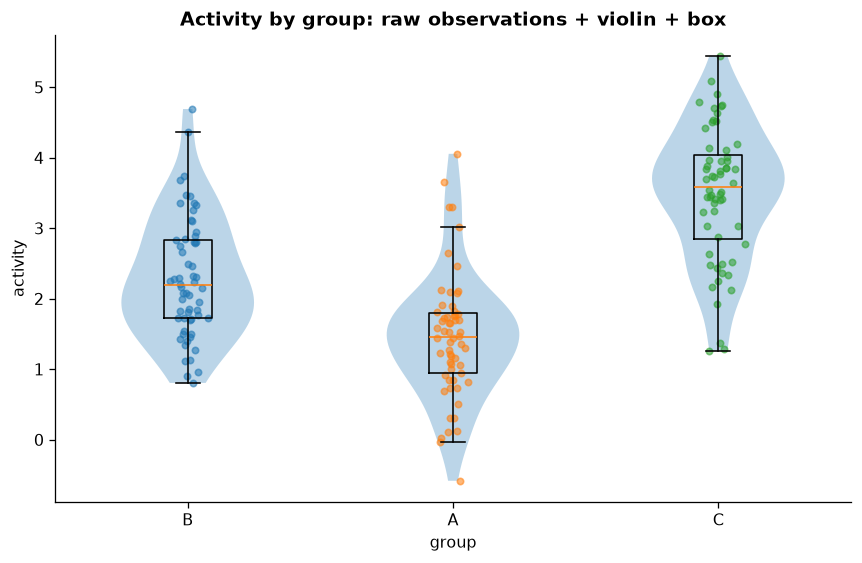

In [2]:
group_violin_box_scatter(frame,value='activity',group='group',title='Activity by group: raw observations + violin + box'); plt.show()

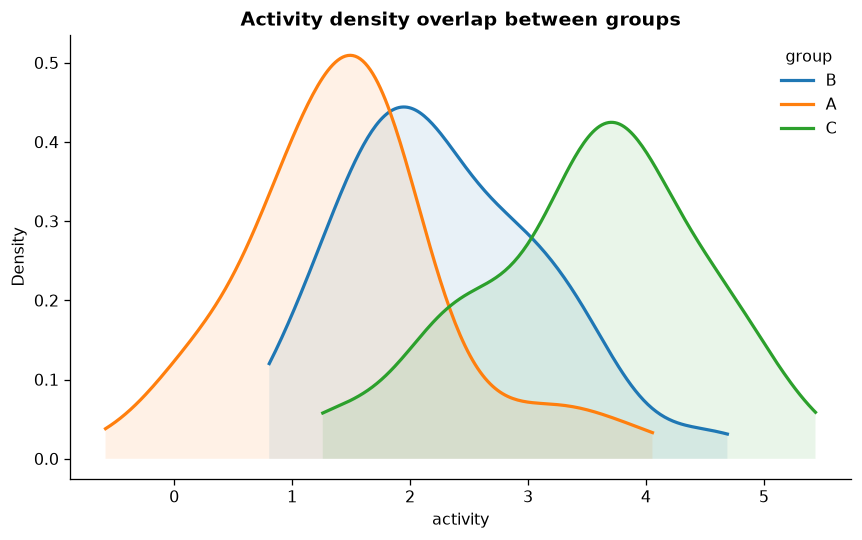

In [3]:
density_by_group(frame,value='activity',group='group',title='Activity density overlap between groups'); plt.show()

## Group means and uncertainty from Ruddy summaries

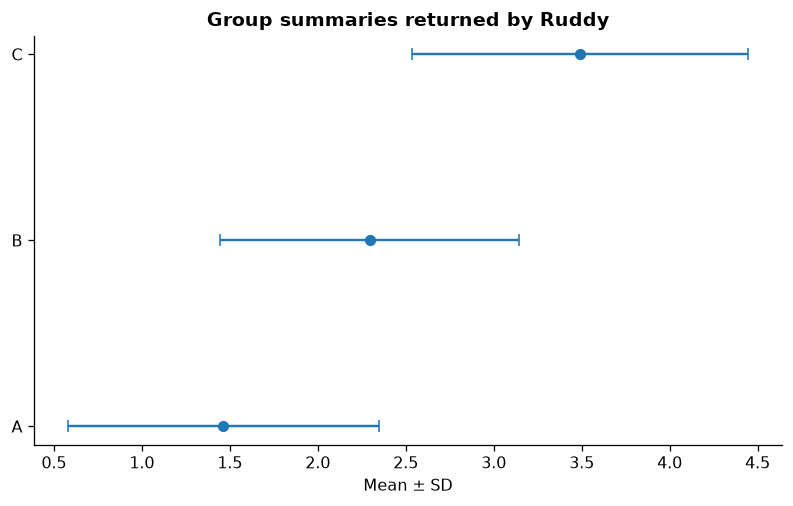

,group_level,mean,std,median,iqr
0,A,1.462774,0.884557,1.458341,0.853195
2,B,2.294916,0.851121,2.188959,1.113100
4,C,3.489166,0.956310,3.590994,1.189372


In [4]:
s=grp.numeric_summaries.query('response=="activity" and group_column=="group"').copy(); s['label']=s.group_level.astype(str)
fig,ax=plt.subplots(figsize=(7,4.5)); ax.errorbar(s['mean'],np.arange(len(s)),xerr=s['std'],fmt='o',capsize=4); ax.set_yticks(np.arange(len(s)),s['label']); ax.set_xlabel('Mean ± SD'); ax.set_title('Group summaries returned by Ruddy'); finish(fig); plt.show(); display(s[['group_level','mean','std','median','iqr']])

## Tukey and Games–Howell side by side

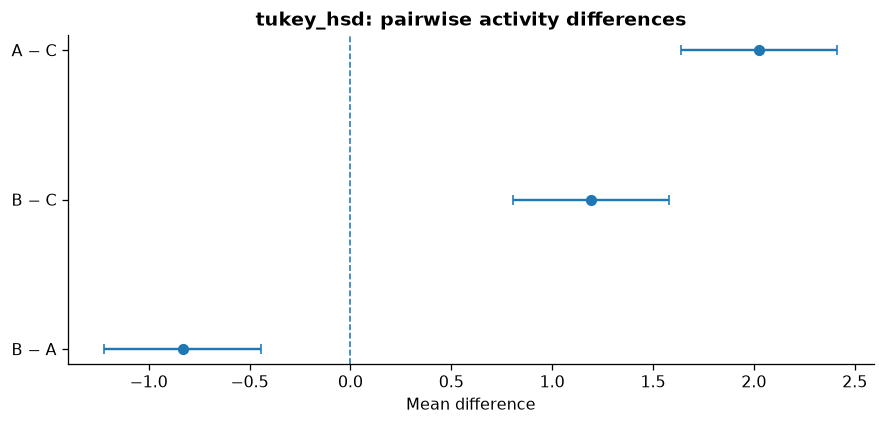

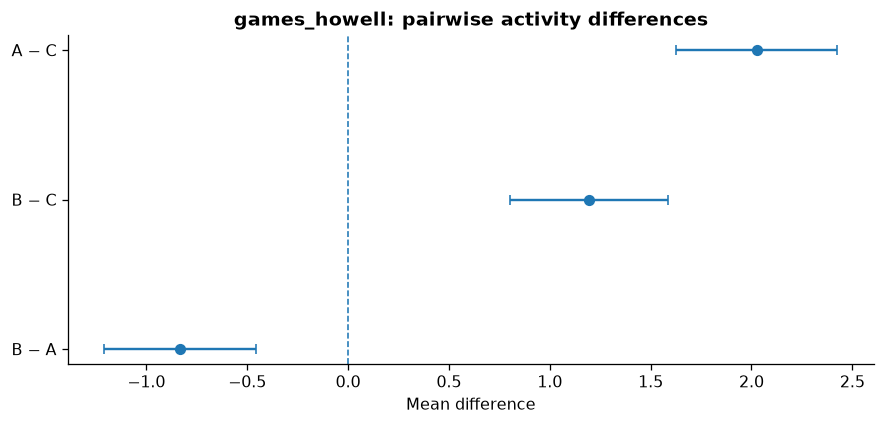

In [5]:
p=post.comparisons.copy(); p['contrast']=p.group_a.astype(str)+' − '+p.group_b.astype(str)
for method in ['tukey_hsd','games_howell']:
    q=p.query('method==@method').copy(); errorbar_table(q,label_col='contrast',estimate_col='mean_difference',low_col='ci_lower',high_col='ci_upper',title=f'{method}: pairwise activity differences',xlabel='Mean difference'); plt.show()

## Effect-size confidence intervals

In [6]:
e=ci.effect_sizes.query('response=="activity" and group=="group" and status=="ok"').copy(); e['contrast']=e.level_a.astype(str)+' − '+e.level_b.astype(str)
if len(e): errorbar_table(e,label_col='contrast',estimate_col='estimate',low_col='confidence_low',high_col='confidence_high',title='Hedges g with bootstrap confidence intervals',xlabel='Standardized effect'); plt.show()

## Pairwise mean-difference matrix

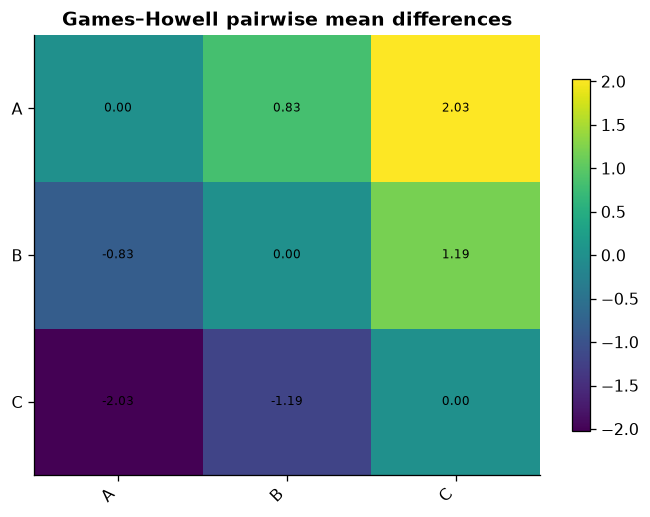

In [7]:
gh=p.query('method=="games_howell"'); levels=sorted(set(gh.group_a).union(gh.group_b)); mat=pd.DataFrame(np.nan,index=levels,columns=levels)
for _,r in gh.iterrows(): mat.loc[r.group_a,r.group_b]=r.mean_difference; mat.loc[r.group_b,r.group_a]=-r.mean_difference
np.fill_diagonal(mat.values,0); matrix_heatmap(mat,title='Games–Howell pairwise mean differences'); plt.show()